In [3]:
include("discrimination_sdp.jl")

discrimination_hierarchy_NALOCC

In [2]:
using LinearAlgebra, DataFrames, PrettyTables
using PrettyTables: Val

"""
    show_discrimination_summary(
        states::Vector{<:AbstractMatrix},
        probabilities::Vector{<:Real},
        dA::Integer,
        dB::Integer,
        m_range::UnitRange{<:Integer};
        seeds::Integer=10,
        iterations::Integer=100,
        tol::Real=1e-6,
        title::AbstractString="Discrimination Performance Summary"
    )

Compute the PPT optimum once, sweep LOCC and Seesaw over `m_range`
(using the optional `seeds`, `iterations`, `tol` for Seesaw),
round all numbers to 2 digits, and display two side-by-side HTML tables
in Jupyter under a single `<h2>` title.

- `states`       : list of density matrices ρᵢ  
- `probabilities`: matching list of prior probabilities  
- `dA`, `dB`     : Hilbert‐space dims of subsystem A and B  
- `m_range`     : e.g. `2:5`  
- `seeds`        : random seeds for seesaw  
- `iterations`   : max seesaw iterations  
- `tol`          : seesaw convergence tolerance  
- `title`        : optional HTML heading
"""


function show_discrimination_summary(
    states::Vector{<:AbstractMatrix},
    probabilities::Vector{<:Real},
    dA::Integer,
    dB::Integer,
    m_range::UnitRange{<:Integer},
    k::Integer;
    decimal_pts::Integer=5,
    seeds::Integer=10,
    iterations::Integer=100,
    verbose::Bool =false,
    threads::Int =1,
    tol::Real=1e-6,
    title::AbstractString="Discrimination Performance Summary"
)
    # 1) PPT optimum
    val_PPT, _ = discrimination_sdp_ppt(states, probabilities, dA, dB)
    val_PPT = round(val_PPT, digits=decimal_pts)

    # 2) Sweep with symmetric SDPs and add LO seesaw
    list_1RLOCC_hierarchy     = Float64[]
    list_NALOCC_hierarchy   = Float64[]
    list_seesaw_1RLOCC  = Float64[]
    list_seesaw_NALOCC    = Float64[]

    for m in m_range
        val_1RLOCC_hierarchy, _  = discrimination_hierarchy_1RLOCC(states, probabilities, dA, dB, m, k; verbose=verbose)
        val_NALOCC_hierarchy, _    = discrimination_hierarchy_NALOCC(states, probabilities, dA, dB, m, k; verbose=verbose)

        val_seesaw_1RLOCC, _, _, _ = discrimination_seesaw_1RLOCC(
            states, probabilities, dA, dB, m;
            seeds=seeds, iterations=iterations, tol=tol,
            threads=threads, verbose=verbose
        )
        val_seesaw_NALOCC, _, _, _ = discrimination_seesaw_NALOCC(states, probabilities, dA, dB, m; seeds=seeds, 
                            iterations=iterations, tol=tol, threads=threads, verbose=verbose)


        push!(list_1RLOCC_hierarchy,    round(val_1RLOCC_hierarchy,   digits=decimal_pts))
        push!(list_NALOCC_hierarchy,  round(val_NALOCC_hierarchy,     digits=decimal_pts))
        push!(list_seesaw_1RLOCC, round(val_seesaw_1RLOCC, digits=decimal_pts))
        push!(list_seesaw_NALOCC,   round(val_seesaw_NALOCC,   digits=decimal_pts))
    end

    # 3) Build DataFrames
    ppt_df = DataFrame(PPT = [val_PPT])
    results = DataFrame(
        m             = m_range,
        Seesaw_1RLOCC    = list_seesaw_1RLOCC,
        hierarchy_1RLOCC   = list_1RLOCC_hierarchy,
        Seesaw_NALOCC      = list_seesaw_NALOCC,
        hierarchy_NALOCC     = list_NALOCC_hierarchy
    )

    # 4) Render helper
    function _table_html(df; header=(names(df), fill("", length(names(df)))))
        buf = IOBuffer()
        pretty_table(
            buf, df;
            header=header, show_row_number=false,
            show_subheader=any(!isempty, header[2]),
            backend=Val(:html),
        )
        String(take!(buf))
    end

    # 5) HTML snippets
    html1 = _table_html(ppt_df)
    hdr    = ["m", "See-saw 1R-LOCC", "Hierarchy 1R-LOCC", "See-saw NA-LOCC", "Hierarchy NA-LOCC"]
    subhdr = ["",   "(lower bound)", "(upper bound)", "(lower bound)", "(upper bound local)"]
    html2  = _table_html(results; header=(hdr, subhdr))

    # 6) Display
    wrapper = """
    <h2 style="font-family:sans-serif">$title</h2>
    <div style="display:flex; gap:2em; align-items:flex-start;">
      $html1
      $html2
    </div>
    """
    display("text/html", wrapper)
end

ArgumentError: ArgumentError: Package DataFrames not found in current path.
- Run `import Pkg; Pkg.add("DataFrames")` to install the DataFrames package.

## Bell family (δ=π/4, τ, ξ=π/2)
$$
\begin{aligned}
\lvert \psi_1 \rangle &= \begin{bmatrix}
0\\[2pt]
\frac{\sqrt{2}}{2}\\[2pt]
\frac{\sqrt{2}\,\sin(\tau)}{2}\\[2pt]
\frac{\sqrt{2}\,\cos(\tau)}{2}
\end{bmatrix}
\qquad
\lvert \psi_2 \rangle &= \begin{bmatrix}
0\\[2pt]
\frac{\sqrt{2}}{2}\\[2pt]
-\frac{\sqrt{2}\,\sin(\tau)}{2}\\[2pt]
\frac{\sqrt{2}\,\cos(\tau)}{2}
\end{bmatrix}
\qquad
\lvert \psi_3 \rangle &= \begin{bmatrix}
-\frac{\sqrt{2}\,i}{2}\\[2pt]
0\\[2pt]
\frac{\sqrt{2}\,\cos(\tau)}{2}\\[2pt]
\frac{\sqrt{2}\,\sin(\tau)}{2}
\end{bmatrix}
\qquad
\lvert \psi_4 \rangle &= \begin{bmatrix}
\frac{\sqrt{2}\,i}{2}\\[2pt]
0\\[2pt]
\frac{\sqrt{2}\,\cos(\tau)}{2}\\[2pt]
\frac{\sqrt{2}\,\sin(\tau)}{2}
\end{bmatrix}
\end{aligned}
$$


In [57]:
using LinearAlgebra, Random
using JLD2
using Plots

# =============== helpers ===============
# piecewise path δ(τ), continuous at τ = π/2
function build_path(num_pts::Int)
    τ = range(0, stop = π/2, length = num_pts)
    δ = fill(π/4, num_pts)
    return τ, δ
end

# =============== knobs ===============
dA, dB = 2, 2
m      = 2
k      = 2
probs  = fill(0.25, 4)

# heatmap grids
num_tau, num_delta = 15, 15
tau_grid   = range(0, π/2; length = num_tau)
delta_grid = range(0, π/4; length = num_delta)

# path resolution for the line plot
num_pts = 15

# seesaw settings
ξ      = float(π/2)
seeds  = 5
iters  = 50
tol    = 1e-6
Random.seed!(1234)

# =============== run ===============
τ_path, δ_path = build_path(num_pts)

# objective value tracks
obj_seesaw_NALOCC        = zeros(num_pts)   # nonadaptive LOCC lower bound
obj_seesaw_1RLOCC        = zeros(num_pts)   # 1 round LOCC lower bound (A → B)
obj_seesaw_1RLOCC_swap   = zeros(num_pts)   # 1 round LOCC lower bound (B → A)
obj_hierarchy_NALOCC     = zeros(num_pts)   # nonadaptive LOCC upper bound
obj_hierarchy_1RLOCC     = zeros(num_pts)   # 1 round LOCC upper bound (A → B)
obj_hierarchy_1RLOCC_sw  = zeros(num_pts)   # 1 round LOCC upper bound (B → A)
obj_PPT                  = zeros(num_pts)   # PPT upper bound

# POVM stores for the seesaw runs
A_seesaw_NALOCC        = Vector{Any}(undef, num_pts)
B_seesaw_NALOCC        = Vector{Any}(undef, num_pts)
A_seesaw_1RLOCC        = Vector{Any}(undef, num_pts)
B_seesaw_1RLOCC        = Vector{Any}(undef, num_pts)
A_seesaw_1RLOCC_swap   = Vector{Any}(undef, num_pts)
B_seesaw_1RLOCC_swap   = Vector{Any}(undef, num_pts)

# state stores
store_states       = Vector{Vector{Matrix{ComplexF64}}}(undef, num_pts)
store_states_swap  = Vector{Vector{Matrix{ComplexF64}}}(undef, num_pts)

for (i, (τ, δ)) in enumerate(zip(τ_path, δ_path))
    # build the iso-entangled basis vectors and states
    v1, v2, v3, v4 = I3_basis(δ, τ, ξ)
    states         = [v * v' for v in (v1, v2, v3, v4)]
    swapped_states = [swap_qubits(v * v') for v in (v1, v2, v3, v4)]

    store_states[i]      = states
    store_states_swap[i] = swapped_states

    # lower bounds via seesaw
    # NA-LOCC
    obj_seesaw_NALOCC[i], A_seesaw_NALOCC[i], B_seesaw_NALOCC[i], _ =
        discrimination_seesaw_NALOCC(states, probs, dA, dB, m;
                                     seeds = seeds, iterations = iters, tol = tol)

    # 1R-LOCC A → B
    obj_seesaw_1RLOCC[i], A_seesaw_1RLOCC[i], B_seesaw_1RLOCC[i], _ =
        discrimination_seesaw_1RLOCC(states, probs, dA, dB, m;
                                     seeds = seeds, iterations = iters, tol = tol)

    # 1R-LOCC B → A (swap qubits to flip direction)
    obj_seesaw_1RLOCC_swap[i], A_seesaw_1RLOCC_swap[i], B_seesaw_1RLOCC_swap[i], _ =
        discrimination_seesaw_1RLOCC(swapped_states, probs, dA, dB, m;
                                     seeds = seeds, iterations = iters, tol = tol)

    # PPT upper bound
    obj_PPT[i], _ = discrimination_sdp_ppt(states, probs, dA, dB)

    # hierarchy upper bounds
    obj_hierarchy_NALOCC[i], _ =
        discrimination_hierarchy_NALOCC(states, probs, dA, dB, m, k)

    obj_hierarchy_1RLOCC[i], _ =
        discrimination_hierarchy_1RLOCC(states, probs, dA, dB, m, k)

    obj_hierarchy_1RLOCC_sw[i], _ =
        discrimination_hierarchy_1RLOCC(swapped_states, probs, dA, dB, m, k)
end

# analytic references at the sampled points
f_vals = @. sin(τ_path)^2 * sin(2 * δ_path)^2     # tangle or chosen reference
g_vals = @. (sqrt(2) * cos(τ_path) + 2) / 4       # keep if you actually use it

# =============== save all data ===============
save_data = Dict(
    "τ_path" => τ_path,
    "δ_path" => δ_path,
    "num_pts" => num_pts,
    "ξ" => ξ,

    # objective values
    "obj_seesaw_NALOCC" => obj_seesaw_NALOCC,
    "obj_seesaw_1RLOCC" => obj_seesaw_1RLOCC,
    "obj_seesaw_1RLOCC_swap" => obj_seesaw_1RLOCC_swap,
    "obj_hierarchy_NALOCC" => obj_hierarchy_NALOCC,
    "obj_hierarchy_1RLOCC" => obj_hierarchy_1RLOCC,
    "obj_hierarchy_1RLOCC_sw" => obj_hierarchy_1RLOCC_sw,
    "obj_PPT" => obj_PPT,

    # POVMs
    "A_seesaw_NALOCC" => A_seesaw_NALOCC,
    "B_seesaw_NALOCC" => B_seesaw_NALOCC,
    "A_seesaw_1RLOCC" => A_seesaw_1RLOCC,
    "B_seesaw_1RLOCC" => B_seesaw_1RLOCC,
    "A_seesaw_1RLOCC_swap" => A_seesaw_1RLOCC_swap,
    "B_seesaw_1RLOCC_swap" => B_seesaw_1RLOCC_swap,

    # states
    "store_states" => store_states,
    "store_states_swap" => store_states_swap,

    # analytic
    "f_vals" => f_vals,
    "g_vals" => g_vals
)

@save "isoentangled_results.jld2" save_data
println("Data saved to isoentangled_results.jld2")



Data saved to isoentangled_results.jld2


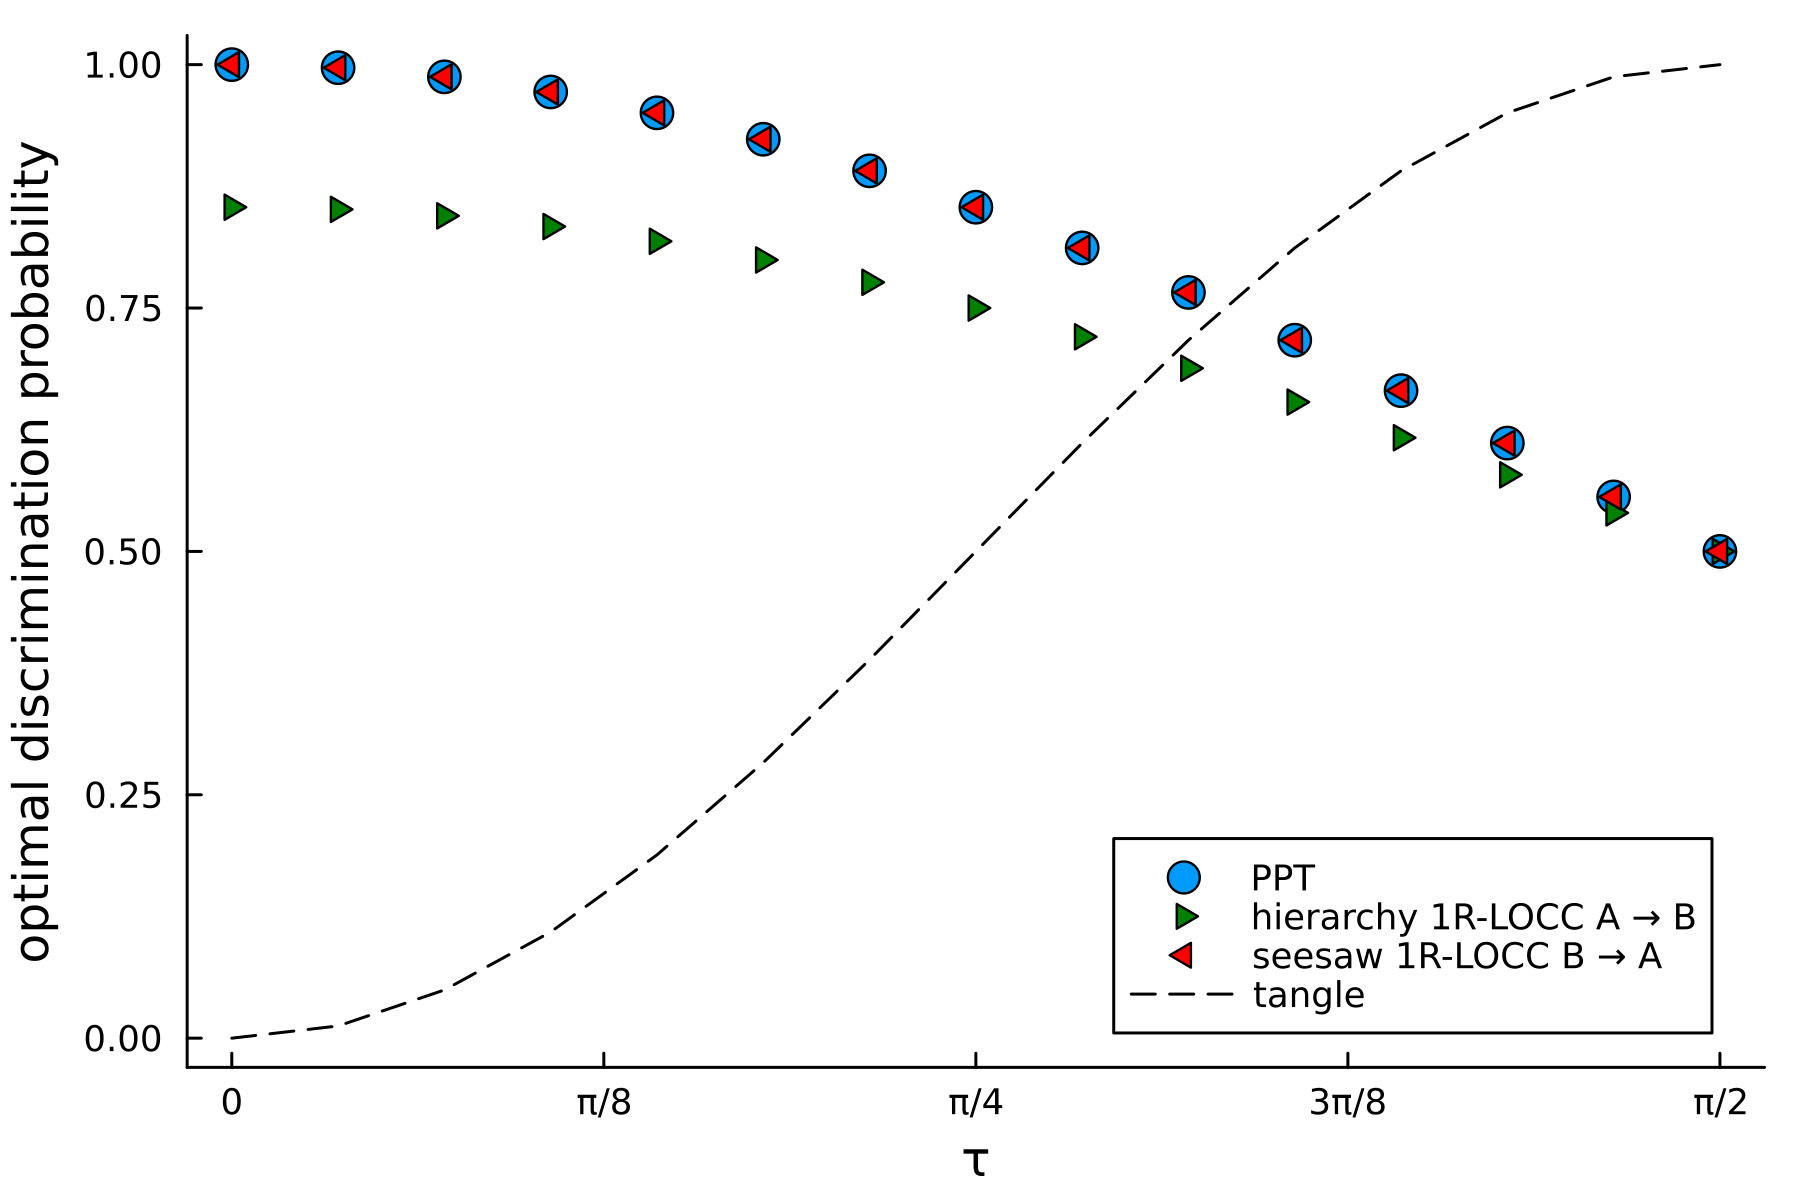

In [1]:
using JLD2, Plots
gr(dpi=300)              # embed 300-dpi metadata in PNGs
default(grid=false)

# load
@load "isoentangled_results.jld2" save_data

# unpack
τ_path                  = save_data["τ_path"]
obj_PPT                 = save_data["obj_PPT"]
obj_hierarchy_1RLOCC    = save_data["obj_hierarchy_1RLOCC"]       # A → B (upper)
obj_seesaw_1RLOCC_swap  = save_data["obj_seesaw_1RLOCC_swap"]     # B → A (lower)
f_vals                  = save_data["f_vals"]

# clear and plot
plot()

# recreate with selected curves
scatter!(τ_path, obj_PPT;                marker=:circle,   markersize=6, label="PPT")
scatter!(τ_path, obj_hierarchy_1RLOCC;   marker=:>, color=:green, markersize=6, label="hierarchy 1R-LOCC A → B")
scatter!(τ_path, obj_seesaw_1RLOCC_swap; marker=:<, color=:red,   markersize=6, label="seesaw 1R-LOCC B → A")

plot!(τ_path, f_vals; label="tangle", color="black", linestyle=:dash)

# custom π ticks
xpos  = [0, pi/8, pi/4, 3pi/8, pi/2]
xlabs = ["0", "π/8", "π/4", "3π/8", "π/2"]
plot!(; xticks=(xpos, xlabs))

xlabel!("τ")
ylabel!("optimal discrimination probability")

# save and show
savefig("isoentangled_results.png")
display(current())


UndefVarError: UndefVarError: `fonts` not defined in `Plots`
Suggestion: check for spelling errors or missing imports.

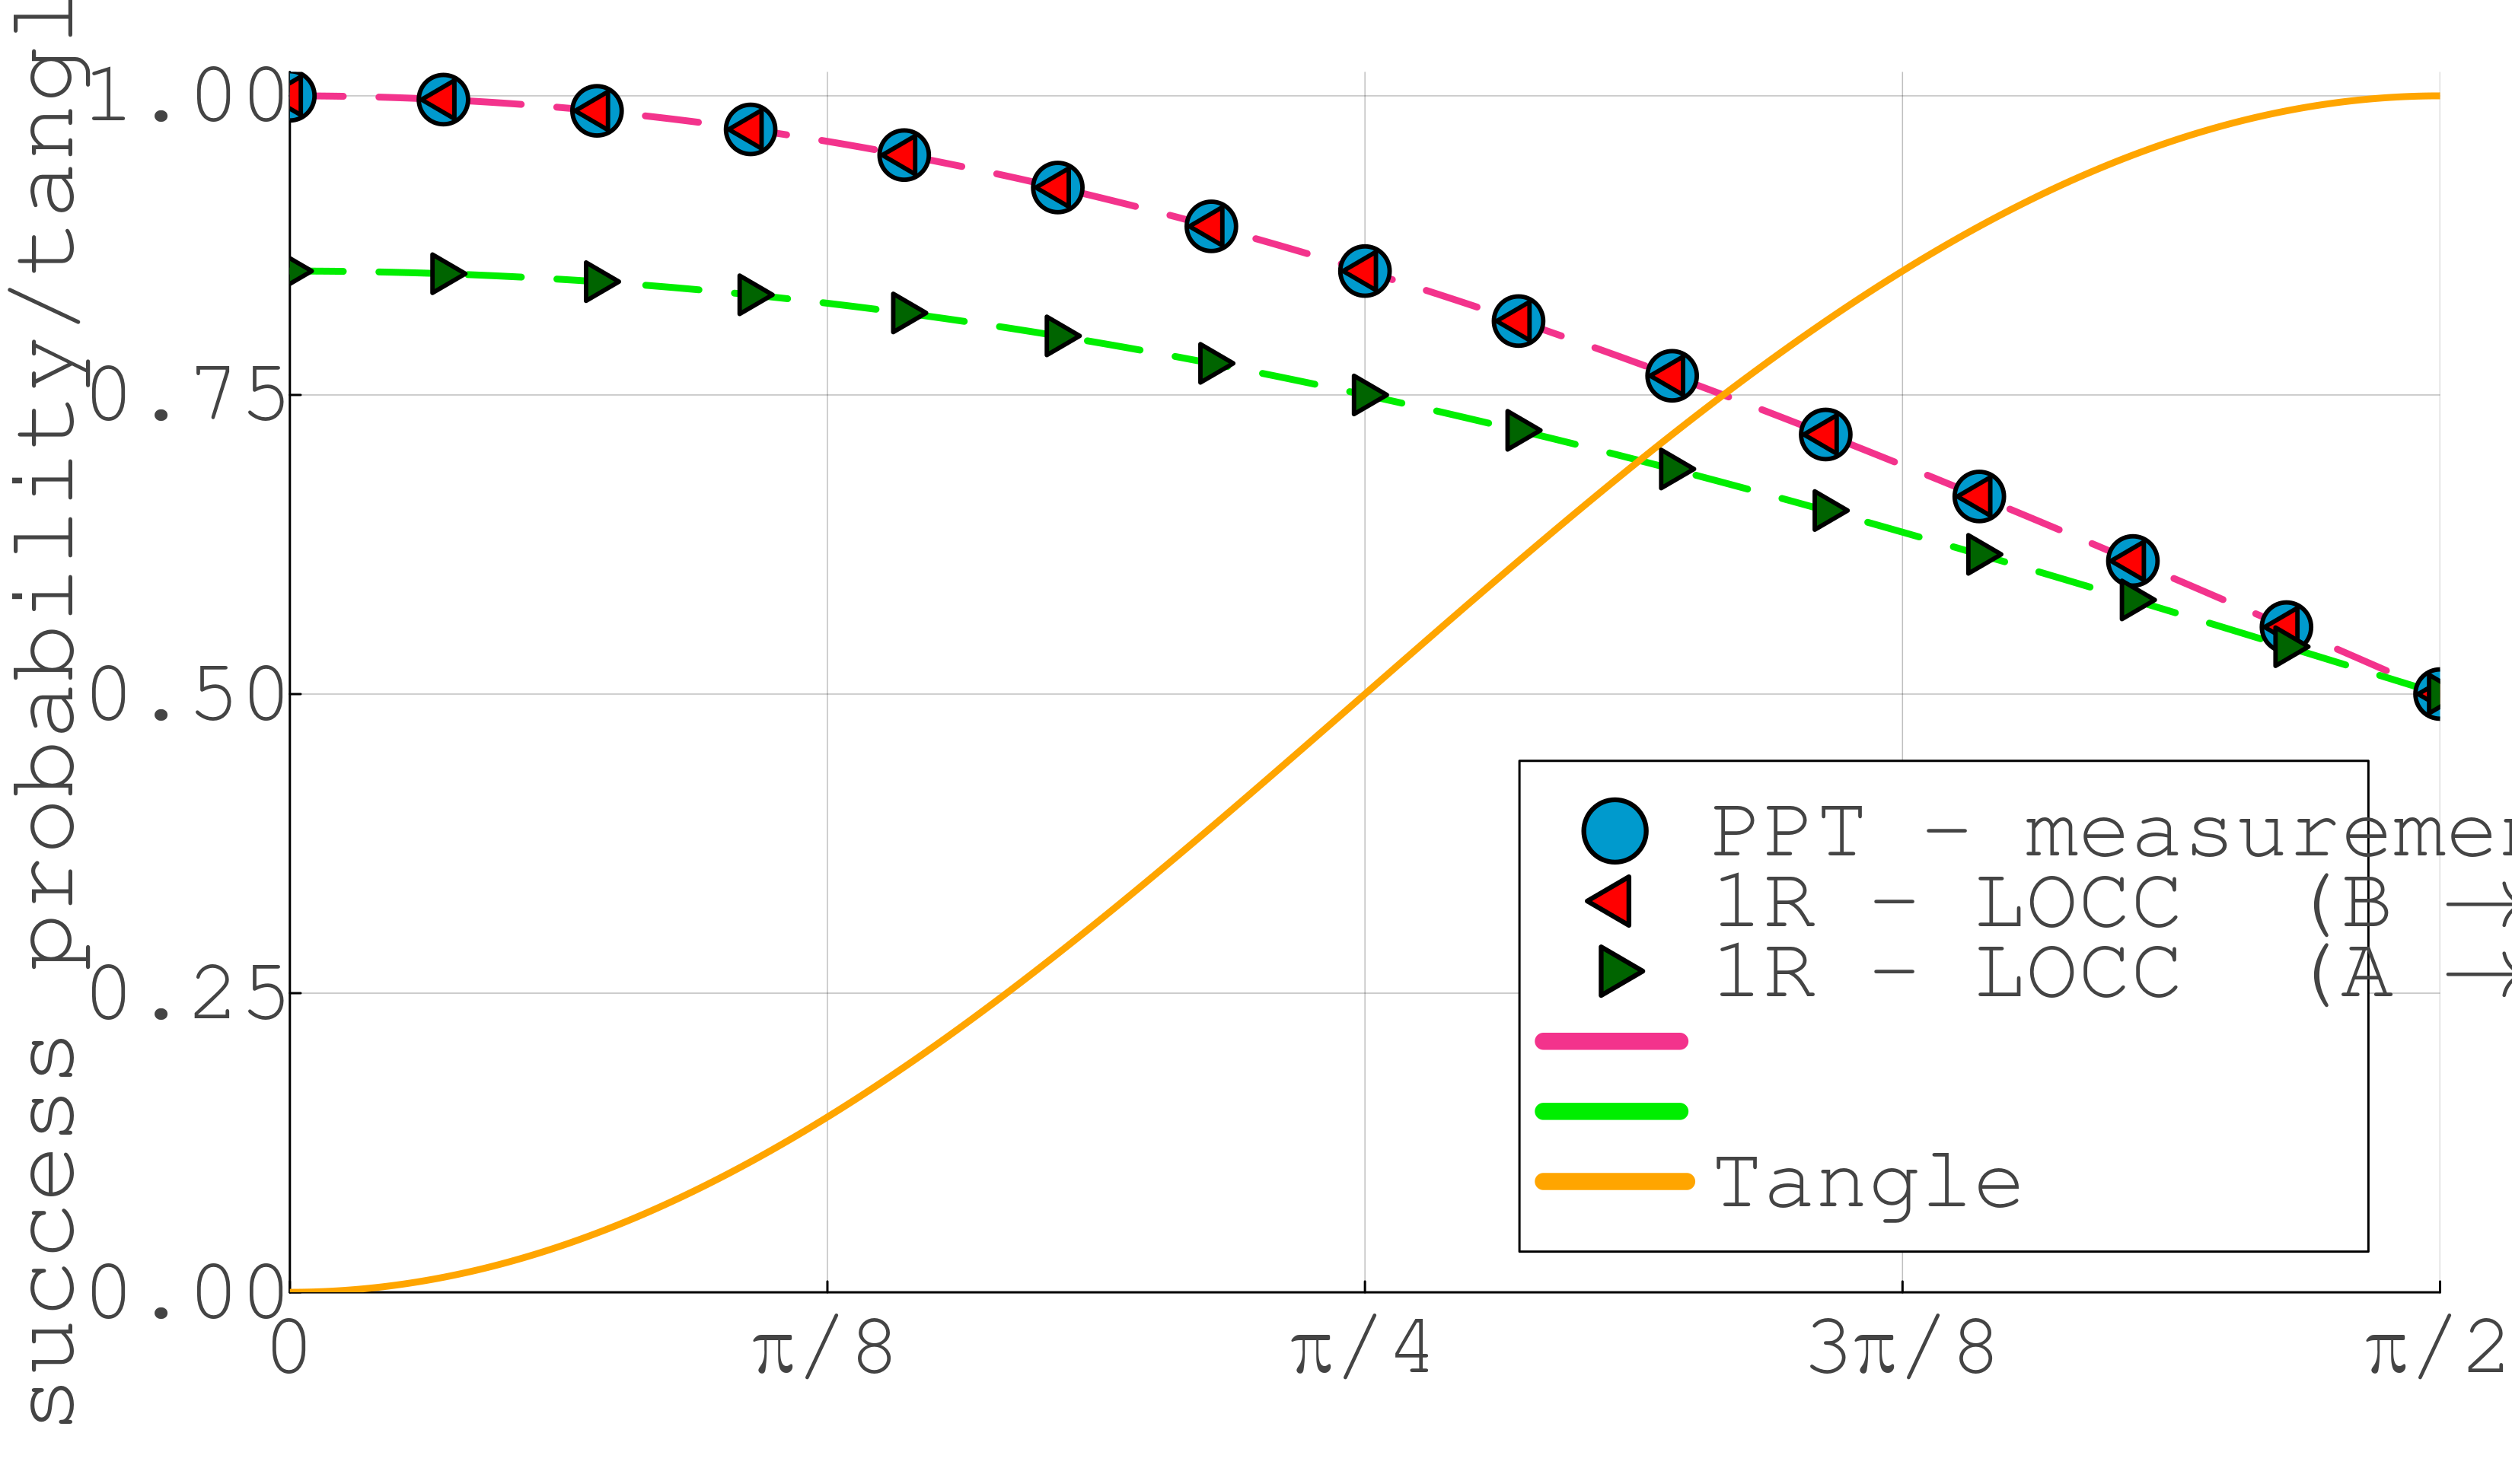

GKS: could not find font CMU Serif.ttf
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8322
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not found
dvipng: PNG conversion failed
sh: 1: dvipng: not 

In [ ]:
using JLD2, Plots, LaTeXStrings
gr(dpi=300)

default(
    grid = true,
    framestyle = :box,
    fontfamily = "Computer Modern",
    linewidth = 2.5,
    size = (1100, 650),
    legendfontsize = 16,
    guidefontsize  = 22,
    tickfontsize   = 16,
    margin = 6Plots.mm,
)

@load "isoentangled_results.jld2" save_data

τ_path                 = save_data["τ_path"]
obj_PPT                = save_data["obj_PPT"]
obj_hierarchy_1RLOCC   = save_data["obj_hierarchy_1RLOCC"]
obj_seesaw_1RLOCC_swap = save_data["obj_seesaw_1RLOCC_swap"]

τ_dense = range(0, π/2; length=600)

f_ppt_curve(τ)  = (cos(τ) + 1) / 2
f_1r_curve(τ)   = (sqrt(2) * cos(τ) + 2) / 4
tangle_curve(τ) = sin(τ)^2

xpos  = [0, π/8, π/4, 3π/8, π/2]
xlabs = ["0", "π/8", "π/4", "3π/8", "π/2"]

p = plot(
    xticks = (xpos, xlabs),
    xlim = (0, π/2),
    ylim = (0, 1.02),
    xlabel = L"\tau",
    ylabel = "success probability/tangle",
    legend = :bottomright,
    gridalpha = 0.25,
)

# -------------------------
# Pass 1: smooth curves BEHIND (no legend entries yet)
# -------------------------
pink  = RGB(0.95, 0.20, 0.55)   



plot!(p, τ_dense, f_ppt_curve.(τ_dense);  label=false, color=pink,         linewidth=3, linestyle=:dash)
plot!(p, τ_dense, f_1r_curve.(τ_dense);   label=false, color=:green2,  linewidth=3, linestyle=:dash)
plot!(p, τ_dense, tangle_curve.(τ_dense); label=false, color=:orange,          linewidth=3)

# -------------------------
# Pass 2: scatters ON TOP (also no legend entries yet)
# -------------------------

scatter!(p, τ_path, obj_PPT;
    label=false,
    marker=:circle, markersize=12,
    color=:deepskyblue3,
    markerstrokewidth=1.5, markerstrokecolor=:black,
)
scatter!(p, τ_path, obj_seesaw_1RLOCC_swap;
    label=false,
    marker=:<, markersize=12,
    color=:red,
    markerstrokewidth=1.5,
)
scatter!(p, τ_path, obj_hierarchy_1RLOCC;
    label=false,
    marker=:>, markersize=12,
    color=:green4,
    markerstrokewidth=1.5,
)

# -------------------------
# Legend-only entries in the order you want
# (use NaN so nothing is drawn in the plot area)
# -------------------------
nanx = [NaN]; nany = [NaN]

scatter!(p, nanx, nany;
    label="PPT – measurement",
    marker=:circle, markersize=14,
    color=:deepskyblue3,
    markerstrokewidth=1.5, markerstrokecolor=:black,
)
scatter!(p, nanx, nany;
    label="1R – LOCC₂ (B → A)",
    marker=:<, markersize=14,
    color=:red,
    markerstrokewidth=1.5,
)
scatter!(p, nanx, nany;
    label="1R – LOCC₂ (A → B)",
    marker=:>, markersize=14,
    color=:green4,
    markerstrokewidth=1.5,
)

plot!(p, nanx, nany;
    label=L"f(\tau)=(\cos\tau+1)/2",
    color=pink, linewidth=3, linestyle=:dash,
)
plot!(p, nanx, nany;
    label=L"g(\tau)=(\sqrt{2}\cos\tau+2)/4",
    color=:green2, linewidth=3, linestyle=:dash,
)
plot!(p, nanx, nany;
    label="Tangle",
    color=:orange, linewidth=3,
)

savefig(p, "isoentangled_results.png")
display(p)


## Double trine
$$
\ket{s_0}=\ket{0},
\qquad
\ket{s_1}=-\frac12\ket{0}-\frac{\sqrt3}{2}\ket{1},
\qquad
\ket{s_2}=-\frac12\ket{0}+\frac{\sqrt3}{2}\ket{1}.
$$


In [54]:
using LinearAlgebra

# dimensions & number of ensemble states
dA, dB = 2, 2
n = 3

# computational basis |0>, |1>
basis(i) = I(2)[:, i]

# single‐qubit “trine” states s_i
s = Vector{Vector{ComplexF64}}(undef, n)
s[1] = basis(1)                              # |s_0> = |0>
s[2] = -1/2*basis(1) - (√3)/2*basis(2)        # |s_1>
s[3] = -1/2*basis(1) + (√3)/2*basis(2)        # |s_2>

# double‐trine pure states |ψ_i> = |s_i> ⊗ |s_i>
ψ = [kron(si, si) for si in s]

# form density matrices ρ_i = |ψ_i⟩⟨ψ_i| and equal probabilities 1/3
states        = [ψi * ψi' for ψi in ψ]
probabilities = fill(1/n, n)


show_discrimination_summary(
    states,
    probabilities,
    dA, dB,        # dA = 2, dB = 3
    2:4,
    1;         # sweep m = 2,3,4,5
    title="Double-Trine Discrimination LOCC"
    )




Double-Trine Discrimination LOCC 
 
 
 
 
 PPT 
 
 
 
 
 0.9714 
 
 
 

 
 
 
 m 
 See-saw 1R-LOCC 
 Hierarchy 1R-LOCC 
 See-saw NA-LOCC 
 Hierarchy NA-LOCC 
 
 
 
 (lower bound) 
 (upper bound, symmetric) 
 (lower bound local) 
 (upper bound local, symmetric) 
 
 
 
 
 2 
 0.89759 
 0.9714 
 0.8003 
 0.93301 
 
 
 3 
 0.93301 
 0.9714 
 0.80789 
 0.9714 
 
 
 4 
 0.93301 
 0.9714 
 0.80789 
 0.9714

## Ququart


   -We want to discriminate the equiprobable ensamble 

\begin{align*}
|\phi_1\rangle &= \frac{1}{2}\bigl(|0\rangle|0\rangle + |1\rangle|1\rangle + |2\rangle|2\rangle + |3\rangle|3\rangle\bigr),\\
|\phi_2\rangle &= \frac{1}{2}\bigl(|0\rangle|3\rangle + |1\rangle|2\rangle + |2\rangle|1\rangle + |3\rangle|0\rangle\bigr),\\
|\phi_3\rangle &= \frac{1}{2}\bigl(|0\rangle|1\rangle + |1\rangle|0\rangle - |2\rangle|3\rangle - |3\rangle|2\rangle\bigr).
\end{align*}



In [63]:
using LinearAlgebra

# 4-dimensional computational basis for each subsystem
basis(i) = I(4)[:, i]   # i=1→|0>, 2→|1>, 3→|2>, 4→|3>

# define the four pure states
φ = Vector{Vector{ComplexF64}}(undef, 3)
φ[1] = 1/2*( kron(basis(1),basis(1)) +
             kron(basis(2),basis(2)) +
             kron(basis(3),basis(3)) +
             kron(basis(4),basis(4)) )
φ[2] = 1/2*( kron(basis(1),basis(4)) +
             kron(basis(2),basis(3)) +
             kron(basis(3),basis(2)) +
             kron(basis(4),basis(1)) )
φ[3] = 1/2*( kron(basis(1),basis(2)) +
             kron(basis(2),basis(1)) -
             kron(basis(3),basis(4)) -
             kron(basis(4),basis(3)) )

# build density matrices and equal weights
states        = [ψ*ψ' for ψ in φ ]
probabilities = fill(1/3, 3)
dA = 4
dB = 4

show_discrimination_summary(
    states,
    probabilities,
    dA, dB,        # dA = 2, dB = 3
    2:3,
    1;         # sweep m = 2,3,4,5
    title="Maximally entangled ququart LOCC"
    )

Maximally entangled ququart LOCC 
 
 
 
 
 PPT 
 
 
 
 
 1.0 
 
 
 

 
 
 
 m 
 See-saw 1R-LOCC 
 Hierarchy 1R-LOCC 
 See-saw NA-LOCC 
 Hierarchy NA-LOCC 
 
 
 
 (lower bound) 
 (upper bound, symmetric) 
 (lower bound local) 
 (upper bound local, symmetric) 
 
 
 
 
 2 
 0.66667 
 0.66667 
 0.66667 
 0.66667 
 
 
 3 
 0.83333 
 1.0 
 0.83333 
 1.0